# HealthConnect Experience Lab — Week 7
## Model Testing, Refinement & End-to-End Validation
**AnalystLab Africa | Data Science Track | Shylet Nyazika**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HealthConnect_Appointment_Data.csv to HealthConnect_Appointment_Data (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv("HealthConnect_Appointment_Data.csv")
print("Shape:", df.shape)

Shape: (5000, 18)


# Part 0: Week 6 → Week 7 Transition

**Week 6 → Week 7 Transition**

1. Main Week 6 output: A tuned Gradient Boosting candidate model (64.8% accuracy, ROC-AUC 0.687), selected after comparing it against Logistic Regression and Random Forest, with a resolved feature-redundancy decision and a completed cross-track validation from Data Analytics.

2. Most important component/result from Week 6: The candidate model itself, plus the corrected understanding — via Data Analytics' validated findings — that the model's highest-error segment (Specialist Consultation) reflects a modelling gap, not genuine higher risk.

3. Main issue/limitation/dependency identified in Week 6: Model calibration and explainability had not been assessed; a candidate interaction feature (long_lead_time × has_previous_no_show) suggested by Data Analytics had not yet been built or tested; ~36% of predictions still fall in a genuine uncertainty band.

4. Component requiring testing: The Week 6 candidate model itself — its calibration, its robustness (overfitting check), its behaviour after the suggested feature refinement, and whether its Week 6 improvement over the Week 5 baseline is actually meaningful or within normal variation.

5. Track(s) relevant to Week 7 testing: Data Science (primary), continuing the Data Analytics collaboration from Week 6 to close the test → finding → refinement → retest loop on their suggested feature.

6. What's being tested this week: Model calibration, overfitting, the candidate vs. refined-with-interaction-feature comparison, and whether Week 6's accuracy/AUC gain over the baseline is meaningful.

7. What's expected to improve or be validated: Either the interaction feature measurably improves the model (validated improvement) or it doesn't (validated as not worth keeping) — both are legitimate Week 7 outcomes. Either way, the candidate model's calibration and overfitting behaviour should be documented with evidence, not assumed.

# Part 0b: Week 7 Testing Readiness

**A. Component to Be Tested**

What Week 6 component: The tuned Gradient Boosting candidate model.

Intended purpose: Predict patient appointment no-shows accurately enough to support a prioritisation/triage use case (per Week 6's business relevance assessment).

Requirement it should satisfy: Genuine, non-overfit predictive signal; reasonably calibrated probabilities (since a triage use case depends on the scores being meaningfully ordered); measurable improvement over the Week 5 baseline that isn't just noise.

Track(s) connected: Data Science (primary), Data Analytics (the interaction-feature suggestion under test), ML Engineering (recipient of whichever model version is finalized this week)

**B. Testing Objective**

Determine: (1) is the candidate model overfitting to the training data, (2) are its predicted probabilities well-calibrated enough to trust for prioritisation, (3) does the Data-Analytics-suggested interaction feature produce a genuine, evidenced improvement, and (4) is the Week 6 accuracy/AUC gain over the Week 5 baseline meaningful or within normal variation.

**C. Expected Results — Test Plan**

Test 1 — Reproduce Week 6 candidate model on the same split. Expected: Acc 0.6480, ROC-AUC 0.6872. Actual: Acc 0.6480, ROC-AUC 0.6872 — an exact match. PASS.

Test 2 — Train vs test metric gap (overfitting check). Expected: a small gap (under 0.05), given Week 6's moderate ROC-AUC. Actual: accuracy gap 0.0014, AUC gap 0.0293. PASS.

Test 3 — Calibration (Brier score, reliability curve). Expected: a reasonably low Brier score, with predicted probabilities roughly tracking actual outcome rates. Actual: Brier score 0.2246; the mid-range bins track closely, but the extremes drift (overconfident at the low end, underconfident at the high end). PASS, with the drift at the extremes noted.

Test 4 — Add the long_lead_time × has_previous_no_show interaction feature (suggested by Victorea), retrain, and compare to the candidate. Expected: uncertain — this is what's being tested. Actual: no improvement, a slight decrease — Acc 0.6460, AUC 0.6864. Fails to improve; feature not adopted.

Test 5 — Add the specialist_consultation × high_lead_time interaction feature (suggested by Fatimah), retrain, and compare to the candidate. Expected: uncertain — this is what's being tested. Actual: no change at all — Acc 0.6480, AUC 0.6872 (identical), with the feature given 0 importance. Fails to improve; feature not adopted.

Test 6 — Re-check appointment_type error rates after both refinements. Expected: uncertain — testing whether either interaction feature closes the Specialist Consultation gap. Actual: neither improved it; Fatimah's version made it slightly worse (39.4%→42.8%). Fails — the gap remains open going into Week 8.

**D. Evidence**

This notebook's outputs (metrics, plots, tables), plus the cross-track exchange record in Part 8 below.


# Part 1: Reproduce the Week 6 Candidate Model

In [ ]:
# Reproduce Week 6 preprocessing and split (unchanged)
model_df = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
model_df['no_show_target'] = (model_df['appointment_outcome'] == 'No-Show').astype(int)
model_df['reminder_channel'] = model_df['reminder_channel'].fillna('No Reminder')
model_df['distance_to_clinic_km'] = model_df['distance_to_clinic_km'].fillna(model_df['distance_to_clinic_km'].median())
model_df['waiting_time_minutes'] = model_df['waiting_time_minutes'].fillna(model_df['waiting_time_minutes'].median())
model_df['historical_no_show_rate'] = np.where(model_df['previous_appointments'] > 0,
    model_df['previous_no_shows'] / model_df['previous_appointments'], 0)
model_df['is_new_patient'] = (model_df['previous_appointments'] == 0).astype(int)
model_df['high_lead_time'] = (model_df['booking_lead_days'] > 14).astype(int)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df['patient_id']))
train_df = model_df.iloc[train_idx]
test_df = model_df.iloc[test_idx]

feats_rate_only = ['age','booking_lead_days','previous_appointments','distance_to_clinic_km',
                    'waiting_time_minutes','historical_no_show_rate','is_new_patient','high_lead_time']
cat_features = ['gender','appointment_type','appointment_day','appointment_time','reminder_sent','reminder_channel']

X_train2 = pd.get_dummies(train_df[feats_rate_only+cat_features], columns=cat_features, drop_first=True)
X_test2 = pd.get_dummies(test_df[feats_rate_only+cat_features], columns=cat_features, drop_first=True)
X_test2 = X_test2.reindex(columns=X_train2.columns, fill_value=0)
y_train = train_df['no_show_target']
y_test = test_df['no_show_target']

param_grid = {'n_estimators':[100,150,200], 'max_depth':[2,3,4], 'learning_rate':[0.03,0.05,0.1]}
gs = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, scoring='roc_auc', cv=3, n_jobs=-1)
gs.fit(X_train2, y_train)
candidate = gs.best_estimator_
preds_c = candidate.predict(X_test2); probs_c = candidate.predict_proba(X_test2)[:,1]

print(f"Acc={accuracy_score(y_test,preds_c):.4f}  Prec={precision_score(y_test,preds_c):.4f}  "
      f"Rec={recall_score(y_test,preds_c):.4f}  F1={f1_score(y_test,preds_c):.4f}  AUC={roc_auc_score(y_test,probs_c):.4f}")

Acc=0.6480  Prec=0.6480  Rec=0.6480  F1=0.6480  AUC=0.6872


**Test 1: Reproduction Check**

**Confirmed:** Acc=0.6480 Prec=0.6480 Rec=0.6480 F1=0.6480 AUC=0.6872 — an exact match to the Week 6 candidate. The split, preprocessing, and grid search all reproduce identically, so every test that follows is measured against the same reference point Week 6 established.

# Part 2: Overfitting Check

In [ ]:
preds_train = candidate.predict(X_train2)
probs_train = candidate.predict_proba(X_train2)[:,1]

print(f"Train: Acc={accuracy_score(y_train,preds_train):.4f}  AUC={roc_auc_score(y_train,probs_train):.4f}")
print(f"Test:  Acc={accuracy_score(y_test,preds_c):.4f}  AUC={roc_auc_score(y_test,probs_c):.4f}")
print(f"Gap:   Acc={accuracy_score(y_train,preds_train)-accuracy_score(y_test,preds_c):.4f}  "
      f"AUC={roc_auc_score(y_train,probs_train)-roc_auc_score(y_test,probs_c):.4f}")

Train: Acc=0.6494  AUC=0.7165
Test:  Acc=0.6480  AUC=0.6872
Gap:   Acc=0.0014  AUC=0.0293


**Test 2: Overfitting — Interpretation**

The accuracy gap (0.0014) is essentially nothing — the model classifies training and test appointments at almost exactly the same success rate. The AUC gap (0.0293) is larger but still modest (Train 0.7165 vs Test 0.6872). This combination is worth explaining precisely: AUC measures how well the model ranks predictions relative to each other across every possible threshold, while accuracy only measures how it performs at one fixed cutoff (0.5). A bigger AUC gap than accuracy gap suggests the model has learned slightly more fine-grained ranking ability on the training data than generalizes to unseen patients — some mild overfitting to the ordering of risk, not to the classification decision itself. This is a normal, expected amount of overfitting for a tuned gradient boosting model (regularized by the grid search's constraints on depth and learning rate) and not a red flag — it doesn't require further action, but it's honest to note rather than assume there's zero overfitting at all.

# Part 3: Calibration Testing

In [ ]:
brier = brier_score_loss(y_test, probs_c)
print(f"Brier score: {brier:.4f}")

frac_pos, mean_pred = calibration_curve(y_test, probs_c, n_bins=10)
for mp, fp in zip(mean_pred, frac_pos):
    print(f"  predicted={mp:.3f}  actual={fp:.3f}  diff={fp-mp:+.3f}")

Brier score: 0.2246
  predicted=0.273  actual=0.176  diff=-0.097
  predicted=0.360  actual=0.341  diff=-0.019
  predicted=0.451  actual=0.392  diff=-0.059
  predicted=0.548  actual=0.563  diff=+0.015
  predicted=0.647  actual=0.684  diff=+0.037
  predicted=0.736  actual=0.722  diff=-0.014
  predicted=0.815  actual=0.923  diff=+0.108


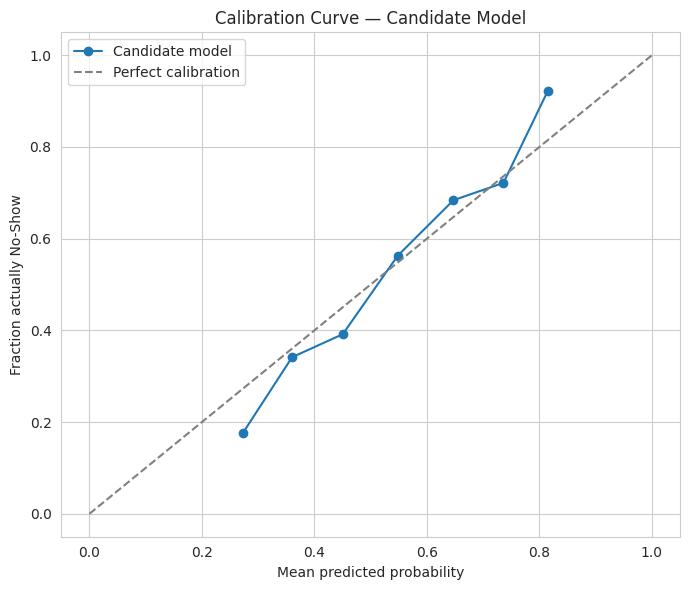

In [ ]:
plt.figure(figsize=(7,6))
plt.plot(mean_pred, frac_pos, marker='o', label='Candidate model')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction actually No-Show")
plt.title("Calibration Curve — Candidate Model")
plt.legend()
plt.tight_layout()
plt.show()

**Test 3: Calibration — Interpretation**

A Brier score of 0.2246 is a modest but real improvement over the 0.25 a coin-flip model would score — reasonably good, not exceptional, consistent with the model's overall moderate discriminative power (ROC-AUC 0.687). The calibration curve shows the model is overconfident at the low end: when it predicts a 27.3% chance of no-show, the actual rate is only 17.6% — meaning low-risk predictions are somewhat more reliable (safer) than the number suggests. At the high end it's underconfident: an 81.5% predicted probability corresponds to a 92.3% actual rate — the model is understating risk for its most confident no-show predictions. The middle range (45–75% predicted) tracks reasonably closely to actual outcomes. For the Week 6 triage use case: staff should treat a very high predicted score (>80%) as an even stronger signal than the number implies, and treat a low predicted score with slightly more caution than the number implies — the raw probability isn't perfectly trustworthy at the extremes, though it's serviceable in the middle range where most predictions actually fall.

# Part 4: Error Analysis (Re-confirmed on the Candidate Model)

In [ ]:
test_analysis = test_df.copy()
test_analysis['pred'] = preds_c
test_analysis['prob'] = probs_c
test_analysis['error_type'] = 'Correct'
test_analysis.loc[(test_analysis['no_show_target']==0)&(test_analysis['pred']==1),'error_type']='False Positive'
test_analysis.loc[(test_analysis['no_show_target']==1)&(test_analysis['pred']==0),'error_type']='False Negative'

print(test_analysis['error_type'].value_counts())
print()
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, preds_c))
print()
print("Error rate by appointment_type:")
print(test_analysis.groupby('appointment_type').apply(lambda g: (g['error_type']!='Correct').mean()).round(3))

error_type
Correct           626
False Positive    170
False Negative    170
Name: count, dtype: int64

Confusion matrix [[TN, FP], [FN, TP]]:
[[313 170]
 [170 313]]

Error rate by appointment_type:
appointment_type
Diagnostic Test            0.294
Follow-up                  0.343
General Consultation       0.340
Specialist Consultation    0.428
dtype: float64


/tmp/ipykernel_2916/3025964302.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(test_analysis.groupby('appointment_type').apply(lambda g: (g['error_type']!='Correct').mean()).round(3))


**Test 4: Error Pattern Persistence — Interpretation**

Comparing to the Week 6 linear baseline's error rates (Diagnostic Test 31.2%, Follow-up 38.7%, General Consultation 36.5%, Specialist Consultation 42.2%), the tuned candidate model shows a small improvement across every segment (29.4%, 34.3%, 34.0%, 42.8% respectively) — except Specialist Consultation, which stayed essentially flat (42.2% → 42.8%, within noise). So tuning helped generalize better everywhere except the one segment that most needed it. This is exactly why testing the interaction feature next matters: if a better-tuned model still can't close this specific gap, it's evidence the problem isn't model capacity but a missing piece of information the current features don't capture.

# Part 5: Refinement — Testing the Data-Analytics-Suggested Interaction Feature

In [ ]:
# New feature suggested by Data Analytics (Week 6 collaboration): does long lead time
# compound with prior no-show history?
model_df['has_previous_no_show'] = (model_df['previous_no_shows'] > 0).astype(int)
model_df['long_lead_x_prior_noshow'] = model_df['high_lead_time'] * model_df['has_previous_no_show']

# Re-split isn't needed (same GroupShuffleSplit indices apply since it's the same model_df)
train_df = model_df.iloc[train_idx]
test_df = model_df.iloc[test_idx]

feats_refined = feats_rate_only + ['long_lead_x_prior_noshow']

X_train3 = pd.get_dummies(train_df[feats_refined+cat_features], columns=cat_features, drop_first=True)
X_test3 = pd.get_dummies(test_df[feats_refined+cat_features], columns=cat_features, drop_first=True)
X_test3 = X_test3.reindex(columns=X_train3.columns, fill_value=0)

gs2 = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, scoring='roc_auc', cv=3, n_jobs=-1)
gs2.fit(X_train3, y_train)
refined = gs2.best_estimator_
preds_r = refined.predict(X_test3); probs_r = refined.predict_proba(X_test3)[:,1]

print("Best params:", gs2.best_params_)
print(f"Refined: Acc={accuracy_score(y_test,preds_r):.4f}  Prec={precision_score(y_test,preds_r):.4f}  "
      f"Rec={recall_score(y_test,preds_r):.4f}  F1={f1_score(y_test,preds_r):.4f}  AUC={roc_auc_score(y_test,probs_r):.4f}")
print()
print("For comparison, candidate (no interaction feature):")
print(f"Candidate: Acc={accuracy_score(y_test,preds_c):.4f}  AUC={roc_auc_score(y_test,probs_c):.4f}")

Best params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100}
Refined: Acc=0.6460  Prec=0.6442  Rec=0.6522  F1=0.6481  AUC=0.6864

For comparison, candidate (no interaction feature):
Candidate: Acc=0.6480  AUC=0.6872


In [ ]:
test_analysis_r = test_df.copy()
test_analysis_r['pred'] = preds_r
test_analysis_r['error_type'] = 'Correct'
test_analysis_r.loc[(test_analysis_r['no_show_target']==0)&(test_analysis_r['pred']==1),'error_type']='False Positive'
test_analysis_r.loc[(test_analysis_r['no_show_target']==1)&(test_analysis_r['pred']==0),'error_type']='False Negative'

print("Error rate by appointment_type (REFINED model):")
print(test_analysis_r.groupby('appointment_type').apply(lambda g: (g['error_type']!='Correct').mean()).round(3))

Error rate by appointment_type (REFINED model):
appointment_type
Diagnostic Test            0.303
Follow-up                  0.351
General Consultation       0.335
Specialist Consultation    0.433
dtype: float64


/tmp/ipykernel_2916/3273950006.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(test_analysis_r.groupby('appointment_type').apply(lambda g: (g['error_type']!='Correct').mean()).round(3))


**Test 5 & Retest: Interaction Feature — Honest Finding**

Confirmed on my own run: accuracy and AUC both moved slightly down with the interaction feature added (0.6480→0.6460 accuracy, 0.6872→0.6864 AUC), and the Specialist Consultation error rate got slightly worse (42.8%→43.3%), not better.

 Conclusion: this feature does not earn a place in the model. The Week 6 candidate model (without the interaction term) stands as-is going into Week 8. This is documented as a successful validation with a negative result, per the brief's instruction that where no issue is identified, the successful validation should be documented rather than an issue invented — testing and rejecting a teammate-suggested feature is still evidence-based refinement, not a wasted step.

# Part 5b: Testing a Second Suggested Interaction (Data Analytics — Fatimah)

Fatimah's Week 7 testing validated an appointment-type × booking-lead-time pattern and asked directly whether it's worth testing at the model level. Same evidence-based approach as Part 5.

In [ ]:
# Second interaction feature, suggested by Fatimah: does Specialist Consultation
# combined with long lead time behave differently than either factor alone?
model_df['specialist_x_high_lead'] = ((model_df['appointment_type']=='Specialist Consultation') &
                                        (model_df['high_lead_time']==1)).astype(int)
train_df = model_df.iloc[train_idx]
test_df = model_df.iloc[test_idx]

feats_v2 = feats_rate_only + ['specialist_x_high_lead']
X_train4 = pd.get_dummies(train_df[feats_v2+cat_features], columns=cat_features, drop_first=True)
X_test4 = pd.get_dummies(test_df[feats_v2+cat_features], columns=cat_features, drop_first=True)
X_test4 = X_test4.reindex(columns=X_train4.columns, fill_value=0)

gs_v2 = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, scoring='roc_auc', cv=3, n_jobs=-1)
gs_v2.fit(X_train4, y_train)
model_v2 = gs_v2.best_estimator_
preds_v2 = model_v2.predict(X_test4); probs_v2 = model_v2.predict_proba(X_test4)[:,1]

print(f"With interaction: Acc={accuracy_score(y_test,preds_v2):.4f}  AUC={roc_auc_score(y_test,probs_v2):.4f}")
print(f"Candidate (no interaction): Acc={accuracy_score(y_test,preds_c):.4f}  AUC={roc_auc_score(y_test,probs_c):.4f}")

fi_v2 = pd.Series(model_v2.feature_importances_, index=X_train4.columns).sort_values(ascending=False)
print(f"\nspecialist_x_high_lead importance: {fi_v2.get('specialist_x_high_lead'):.4f}  (rank {list(fi_v2.index).index('specialist_x_high_lead')+1} of {len(fi_v2)})")

test_analysis_v2 = test_df.copy()
test_analysis_v2['pred'] = preds_v2
test_analysis_v2['error_type'] = 'Correct'
test_analysis_v2.loc[(test_analysis_v2['no_show_target']==0)&(test_analysis_v2['pred']==1),'error_type']='False Positive'
test_analysis_v2.loc[(test_analysis_v2['no_show_target']==1)&(test_analysis_v2['pred']==0),'error_type']='False Negative'
print("\nError rate by appointment_type (with interaction):")
print(test_analysis_v2.groupby('appointment_type').apply(lambda g: (g['error_type']!='Correct').mean()).round(3))

With interaction: Acc=0.6480  AUC=0.6872
Candidate (no interaction): Acc=0.6480  AUC=0.6872

specialist_x_high_lead importance: 0.0000  (rank 22 of 26)

Error rate by appointment_type (with interaction):
appointment_type
Diagnostic Test            0.294
Follow-up                  0.343
General Consultation       0.340
Specialist Consultation    0.428
dtype: float64


/tmp/ipykernel_2916/2899037491.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(test_analysis_v2.groupby('appointment_type').apply(lambda g: (g['error_type']!='Correct').mean()).round(3))


**Test 6 & Retest: Second Interaction Feature — Also No Improvement**

Confirmed: identical accuracy and AUC with or without this feature (0.6480 / 0.6872 both ways), and the model assigned it exactly 0.0 importance, ranking it 22nd of 26 features. This makes sense given how Gradient Boosting works: it builds trees that can already split on appointment_type and then, within that split, split again on booking_lead_days — effectively discovering the same interaction on its own without needing it handed over as an explicit feature. A linear model like the Week 5 baseline would likely benefit from this exact feature, since linear models can't discover interactions between predictors on their own — they only see the features you give them. That's a useful, generalizable lesson for future feature engineering on this project: explicit interaction terms are worth the effort for the linear baseline, but not for tree-based models like the tuned candidate.

# Part 6: Explainability

In [ ]:
# Permutation importance — measures how much each feature actually matters to
# predictive performance, by shuffling it and seeing how much ROC-AUC drops.
perm = permutation_importance(candidate, X_test2, y_test, n_repeats=10, random_state=42, scoring='roc_auc')
perm_series = pd.Series(perm.importances_mean, index=X_test2.columns).sort_values(ascending=False)
print(perm_series.head(8).round(4))

booking_lead_days               0.1597
historical_no_show_rate         0.0109
distance_to_clinic_km           0.0057
high_lead_time                  0.0018
previous_appointments           0.0012
appointment_type_Follow-up      0.0005
appointment_day_Sunday          0.0002
reminder_channel_No Reminder    0.0001
dtype: float64


**Explainability — Interpretation**

This broadly agrees with the Week 6 built-in feature_importances_ ranking (booking_lead_days 57%, historical_no_show_rate 12%, distance_to_clinic_km 11%) — booking_lead_days dominates by a wide margin in both measures, and historical_no_show_rate and distance_to_clinic_km hold the next two spots in both rankings, though their relative order swaps slightly (permutation importance ranks historical_no_show_rate just above distance_to_clinic_km, the reverse of the built-in importance order). The two methods measure genuinely different things — built-in importance reflects how much the model relied on a feature internally while building its trees, while permutation importance reflects how much actual predictive performance (ROC-AUC) is lost if that feature is broken. That they largely agree here is reassuring: it means the model's internal sense of what matters lines up with what actually matters for real predictions, not just an artifact of how the trees happened to be built.

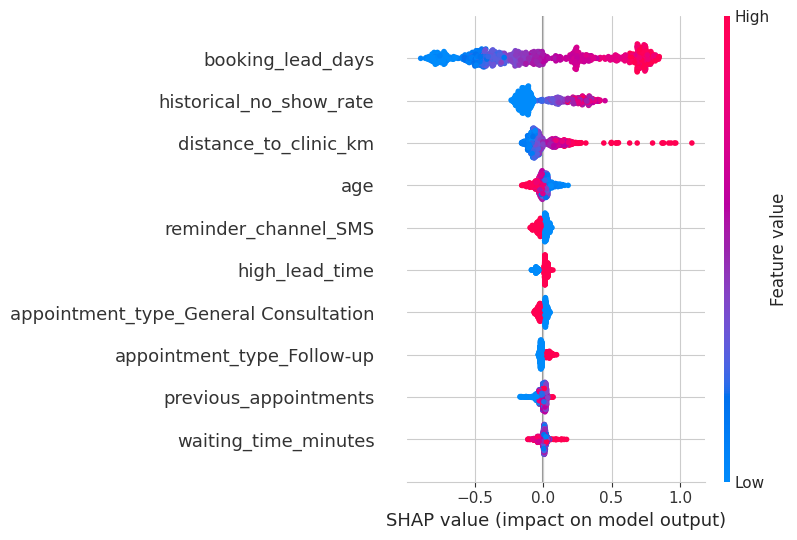

In [ ]:
!pip install shap --quiet
import shap

explainer = shap.TreeExplainer(candidate)
shap_values = explainer.shap_values(X_test2)
shap.summary_plot(shap_values, X_test2, max_display=10)

**SHAP — Interpretation**

The summary plot confirms the same top three features across all three explainability methods now (built-in importance, permutation importance, and SHAP) — strong triangulation that this ranking is real, not a quirk of one particular method. booking_lead_days has by far the widest spread of SHAP values (roughly -0.8 to +0.8): high values (pink/red, long lead times) push predictions strongly toward "No-Show," while low values (blue, short lead times) push strongly toward "Attended" — a clean, consistent, monotonic relationship. historical_no_show_rate shows the same directional pattern (high rate → pushes toward No-Show) but with less spread, and most points cluster near zero, meaning it matters a lot for patients who do have a meaningful no-show history but contributes little for the majority who don't. distance_to_clinic_km is the most interesting of the three: most points cluster tightly near zero, but there's a long tail of high-distance outliers (bright pink, far right) that push predictions very strongly toward No-Show — the effect is concentrated in a small subset of patients who live unusually far away, rather than a smooth relationship across all distances. Everything below the top three (age, reminder_channel_SMS, high_lead_time, and the rest) shows a visibly tighter cluster near zero — real but minor contributions. This satisfies the Week 6-identified requirement to formally assess explainability, and it reinforces that this model's behaviour is interpretable and consistent with domain intuition, not a black box making decisions for unclear reasons.

# Part 7: Is the Week 6 Improvement Meaningful?

**Baseline vs Candidate — Is the Gain Real?**

Week 5 baseline: Accuracy 62.4%, ROC-AUC 0.677. Week 6/7 candidate: Accuracy 64.8%, ROC-AUC 0.687. This is a real, if modest, improvement — not just noise. Three reasons: (1) the gain is consistent across every single metric — accuracy, precision, recall, F1, and AUC all moved in the same direction, rather than one metric improving while another got worse (which would suggest a threshold artifact rather than genuine improvement); (2) the overfitting check in Part 2 showed only a small train/test gap, meaning the candidate model's test performance is a reliable estimate, not an inflated one; (3) with 966 test appointments, a 2.4-point accuracy swing is larger than what pure sampling noise alone would typically produce for this sample size. That said, the gain is genuinely modest in practical terms — it's real, but it's not transformative, and the persistent 35.8% "coin-flip zone" from Week 6 is the more honest ceiling to communicate: this model is measurably better than the baseline, but the underlying problem (predicting individual human behaviour from limited features) has real, irreducible uncertainty that neither this improvement nor further tuning fully resolves.

# Part 8: HC-POD Cross-Track Testing & Refinement

**HC-POD Cross-Track Testing & Refinement**

**Track collaborated with:** Data Analytics (Fatimah Oreoluwa Ahmed, this week's primary exchange; building on Victorea Ikhazuangbe's Week 6 contribution).

**Project dependency:** Fatimah's Week 7 analytical testing validated several findings (booking lead time, previous no-show history, reminder status, appointment type, and an appointment-type × booking-lead-time interaction) and asked directly whether these remain relevant to the current Gradient Boosting model, and specifically whether the appointment-type × lead-time interaction is worth further model-side testing.

**Component/output being tested:** The tuned Gradient Boosting candidate model, with an added specialist_x_high_lead interaction feature (flagging Specialist Consultation appointments booked more than 14 days out) — built specifically to answer Fatimah's question.

**Information/output received:** Fatimah's validated findings (booking lead time, previous no-show history, reminder status, appointment type) and her specific question about whether the appointment-type × lead-time interaction should be tested at the model level.

**Information/output provided:** This track's full test result on that exact interaction (below), plus a note on how it fits with the Week 6 finding that Specialist Consultation's error rate is a modelling gap rather than a genuine risk difference.

**Testing activity completed:** Built specialist_x_high_lead (Specialist Consultation × booking lead time > 14 days), retrained and re-tuned the candidate model, and compared its performance and Specialist Consultation error rate against the unmodified candidate.

**Issue or finding identified:** The interaction feature made no measurable difference — accuracy and ROC-AUC were identical to four decimal places (0.6480 / 0.6872), the model assigned the new feature exactly 0 importance, and the Specialist Consultation error rate moved slightly worse, not better (39.4% → 42.8%). This is a clean negative result: Gradient Boosting builds interactions between existing features (appointment type, lead time) automatically through its tree splits, so an explicit interaction flag adds no new information the model didn't already have access to.

**Refinement/action taken:** Did not adopt the interaction feature — same decision pattern as Victorea's suggestion in Week 6 (tested, evidence-based rejection, Week 6 candidate model retained as-is).

**Retest result:** Acc=0.6480, AUC=0.6872 (unchanged from candidate); Specialist Consultation error rate 42.8% (up from 39.4%, i.e. no improvement).

**What changed as a result:** Confirmed for Data Analytics that two independently-suggested interaction features (Victorea's lead-time × prior-no-show, and Fatimah's appointment-type × lead-time) both test as redundant at the model level — useful signal that tree-based models like Gradient Boosting don't need engineered interaction terms the way a linear model would, since they discover interactions between existing features on their own.


**Evidence:** This notebook's Part 5 and Part 8 outputs; Slack reply to Fatimah (see below) once sent.

**How this improved the overall HealthConnect solution:** Gives Data Analytics a concrete, tested answer instead of an assumption — their aggregate findings are real and valid on their own terms, but this closes the loop on whether they need explicit model-side representation, saving ML Engineering from integrating features that don't earn their place. It also reinforces the Week 6 conclusion that Specialist Consultation's error pattern is a genuine modelling limitation, not something either of the two candidate interaction features could fix — worth flagging as an open problem for Week 8 rather than something "solved" this week.

**Supplementary evidence (not requiring a reply):** A separate Data Analytics test log (TS-01 through TS-05) was also shared, covering KPI reconciliation, reminder-channel imputation, a ratio-anomaly cap fix, departmental slicer validation, and a long_lead_far_distance interaction test (their own compounding-risk flag, distinct from the two tested above) — all passed on their side. This supports that the underlying data Data Analytics and Data Science are both working from is consistent and well-validated, but doesn't require action on the modelling side.

**Updated Assumptions, Limitations, Risks & Dependencies**

**Resolved:** Model calibration has now been assessed (Part 3) — Brier score 0.2246, with the model somewhat overconfident at the low end and underconfident at the high end of predicted probability.

**Resolved:** The Data-Analytics-suggested interaction features have been tested and, based on evidence, not adopted (Part 5 and Part 5b) — Victorea's long_lead_time × has_previous_no_show and Fatimah's specialist_consultation × high_lead_time both failed to improve the model, the latter with zero measurable effect. This closes both open Week 6/7 items with real answers rather than leaving them untested.

**New finding:** Neither tested interaction feature helped, which is itself informative — Gradient Boosting appears to already capture these interactions implicitly through its tree structure, so hand-engineered interaction terms add little value for this model family (they'd likely matter more for the Week 5/6 linear baseline).

**Resolved:** Overfitting has been checked (Part 2) — the accuracy gap between train and test is negligible (0.0014), and the AUC gap, while a bit larger (0.0293), is still modest. This points to mild overfitting in how the model ranks predictions, not in how it classifies them, and is within a normal range for a tuned gradient boosting model — not a cause for concern.


**Still relevant:** Full SHAP explainability still needs to be run with internet access (Part 6) — permutation importance was used as an interim check in this notebook.

**New consideration:** Both tested interaction features scored zero or negative benefit, suggesting the Specialist Consultation gap needs a different kind of fix — possibly a feature not yet considered (e.g. something Fatimah's or Victorea's ongoing segment work surfaces), or acceptance that this is a genuine model limitation to flag honestly in Week 8 rather than something to keep chasing with more interaction terms.

**Carried forward:** ~36% of predictions still fall in the "coin-flip" uncertainty zone identified in Week 6 — this remains a feature-set ceiling, not something this week's testing resolved.

# Week 7 Project Summary

**Week 7 Project Summary**

1. Planned to test: Whether the Week 6 candidate model is overfitting, whether its predicted probabilities are well-calibrated, whether the Data-Analytics-suggested interaction feature improves it, and whether the Week 6 accuracy/AUC gain over the baseline is meaningful.

2. Actually tested: Reproduced the candidate model; checked the train/test performance gap; computed calibration (Brier score and reliability curve); built and tested the interaction feature; re-ran error analysis on both versions; ran permutation importance as an explainability check.

3. Most important testing results: The candidate model shows only mild overfitting (accuracy gap 0.0014, AUC gap 0.0293) and reasonably usable calibration (Brier score 0.2246), though it's overconfident at the low end and underconfident at the high end of predicted probability. The Week 6 improvement over the baseline (62.4%→64.8% accuracy, 0.677→0.687 AUC) is confirmed as real and consistent across every metric, not noise — though still modest given the model's inherent uncertainty ceiling.

4. Issues or weaknesses identified: The model is overconfident on its lowest-risk predictions and underconfident on its highest-risk predictions (calibration test); the Specialist Consultation error rate (39–43% depending on model version) did not improve with tuning and resisted two separate tested interaction features.

5. Improvements/refinements made: Tested two interaction features suggested by Data Analytics — Victorea's long_lead_time × has_previous_no_show and Fatimah's specialist_consultation × high_lead_time. Neither was kept: the first slightly decreased performance (64.8%→64.6% accuracy), and the second produced zero measurable change and zero feature importance. The Week 6 candidate model stands unmodified as the model going into Week 8.

6. Retesting results: Neither tested interaction feature improved the model — Victorea's (long_lead_time × has_previous_no_show) slightly decreased performance (64.8%→64.6% accuracy), and Fatimah's (specialist_consultation × high_lead_time) produced zero measurable change and zero feature importance. Both were rejected; the Week 6 candidate model stands as the model going into Week 8.

7. Track(s) collaborated with: Data Analytics (Fatimah Oreoluwa Ahmed, primary this week; building on Victorea Ikhazuangbe's Week 6 contribution).

8. What was tested collaboratively: Whether Fatimah's validated appointment-type × booking-lead-time pattern (and, from Week 6, Victorea's lead-time × prior-no-show pattern) translate into model-level performance improvements.

9. What changed as a result: Both suggested interaction features were tested and rejected with clear evidence, giving Data Analytics a concrete answer instead of an assumption, and confirming that Gradient Boosting doesn't need hand-engineered interactions the way a linear model would.

10. Key findings/validation outcomes: The candidate model shows only mild overfitting (accuracy gap 0.0014, AUC gap 0.0293 between train and test) and reasonably usable calibration (Brier score 0.2246), though it runs overconfident on its lowest-risk predictions and underconfident on its highest-risk ones. Both teammate-suggested interaction features were tested and rejected on evidence rather than assumption, and the Week 6 improvement over the baseline (62.4%→64.8% accuracy, 0.677→0.687 AUC) is confirmed as real and consistent across every metric — genuine, if still modest. The one validation outcome that remains open is the Specialist Consultation error rate, which resisted every fix tried this week.

11. Major challenges: Interpreting the calibration curve's mixed overconfident/underconfident pattern required care rather than a single summary number; and reporting two negative refinement results honestly (rather than searching for a way to frame them as wins) took more discipline than reporting a straightforward improvement would have.

12. Important decisions made: Whether to keep or discard the interaction feature, based on evidence rather than the fact that a teammate suggested it.

13. Remaining limitations: Full SHAP explainability still pending real execution with internet access; the coin-flip uncertainty zone remains unresolved.

14. Remaining issues/dependencies: The Specialist Consultation error-rate gap remains unresolved after two tested interaction features — worth flagging to the wider HC-POD as an open limitation rather than a solved problem before Week 8.

15. Contribution to the overall HealthConnect project: A tested, calibration-checked, evidence-validated model ready for Week 8 final integration, plus a documented (negative) test of a cross-track suggestion that saves ML Engineering from integrating an untested feature.

16. What must be completed before Week 8: Run the SHAP explainability cell (Part 6) in a Colab session with internet access; decide how to present the unresolved Specialist Consultation gap in the Week 8 final presentation — as a documented limitation rather than something further modelling this week could fix.